In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

from sklearn.manifold import TSNE

In [11]:
edges = np.load("data/processed/edges.npz")
recipes = pd.read_csv("data/processed/recipes.csv")
ingr_map = pd.read_csv("data/processed/ingredient_map.csv")
ingr = pd.read_csv("data/processed/ingredients.csv")
node2vec = np.load("data/node2vec/embeddings.npz")

In [ ]:
def plot_embedding_by_ingredient(
    ingredient,
    embeddings=None,
    recipes_df=None,
    title=None,
    figsize=(10, 8),
    alpha=0.6,
    point_size=12,
):
    """Plot recipe embeddings, coloring recipes by ingredient membership."""
    if embeddings is None:
        embeddings = node2vec["recipe_embeddings"]
    if recipes_df is None:
        recipes_df = recipes

    if len(embeddings) != len(recipes_df):
        raise ValueError(
            "The number of embeddings must match the number of recipe rows."
        )
    if "ings" not in recipes_df:
        raise ValueError("recipes_df must contain an 'ings' column.")

    ingredient = ingredient.strip().lower()
    if not ingredient:
        raise ValueError("ingredient must not be empty.")

    has_ingredient = recipes_df["ings"].fillna("").map(
        lambda value: ingredient in {
            item.strip().lower() for item in value.split("|") if item.strip()
        }
    ).to_numpy()

    if len(embeddings) < 3:
        raise ValueError("t-SNE requires at least three embeddings.")
    coordinates = TSNE(
        n_components=2,
        perplexity=min(30, len(embeddings) - 1),
        init="pca",
        learning_rate="auto",
        random_state=0,
    ).fit_transform(embeddings)

    figure, axis = plt.subplots(figsize=figsize)
    axis.scatter(
        coordinates[~has_ingredient, 0],
        coordinates[~has_ingredient, 1],
        c="lightgray",
        alpha=alpha,
        s=point_size,
        label="Does not contain ingredient",
    )
    axis.scatter(
        coordinates[has_ingredient, 0],
        coordinates[has_ingredient, 1],
        c="tab:red",
        alpha=alpha,
        s=point_size,
        label=f"Contains {ingredient}",
    )
    axis.set_title(title or f"Recipe embeddings colored by '{ingredient}'")
    axis.set_xlabel("t-SNE dimension 1")
    axis.set_ylabel("t-SNE dimension 2")
    axis.legend()
    figure.tight_layout()
    plt.show()

    print(f"Recipes containing {ingredient!r}: {has_ingredient.sum():,}")
    print(f"Other recipes: {(~has_ingredient).sum():,}")

    return figure, axis

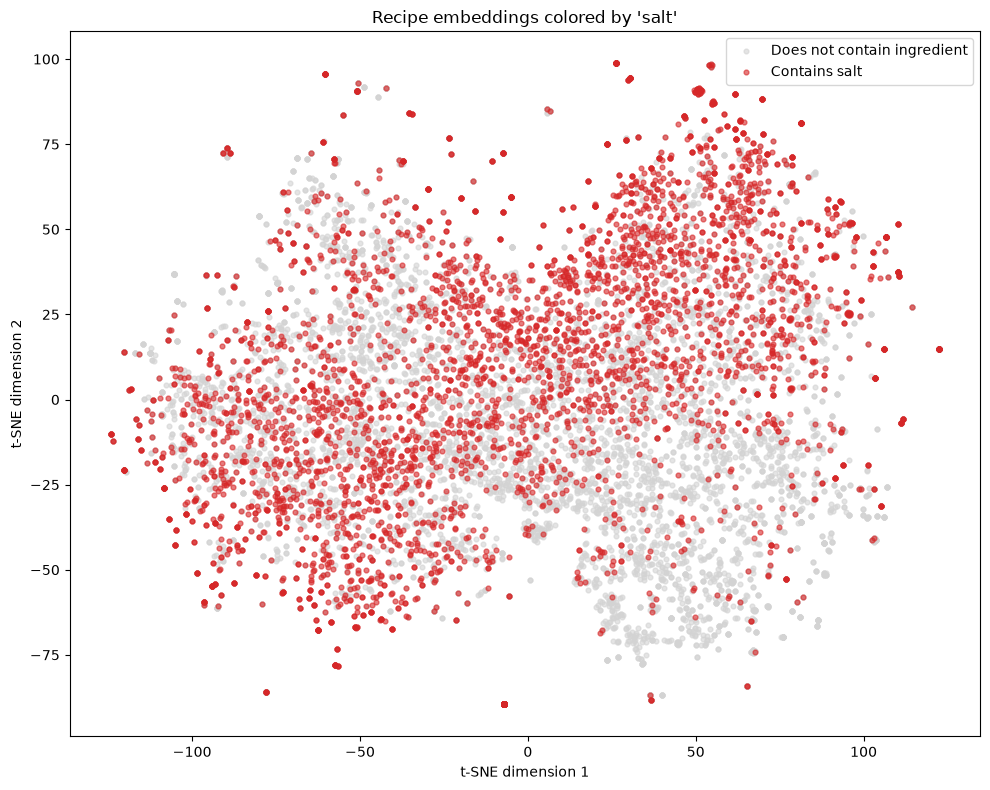

Recipes containing 'salt': 3,917
Other recipes: 5,912


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': "Recipe embeddings colored by 'salt'"}, xlabel='t-SNE dimension 1', ylabel='t-SNE dimension 2'>)

In [13]:
shared_ingredient = 'salt'
plot_embedding_by_ingredient(shared_ingredient)

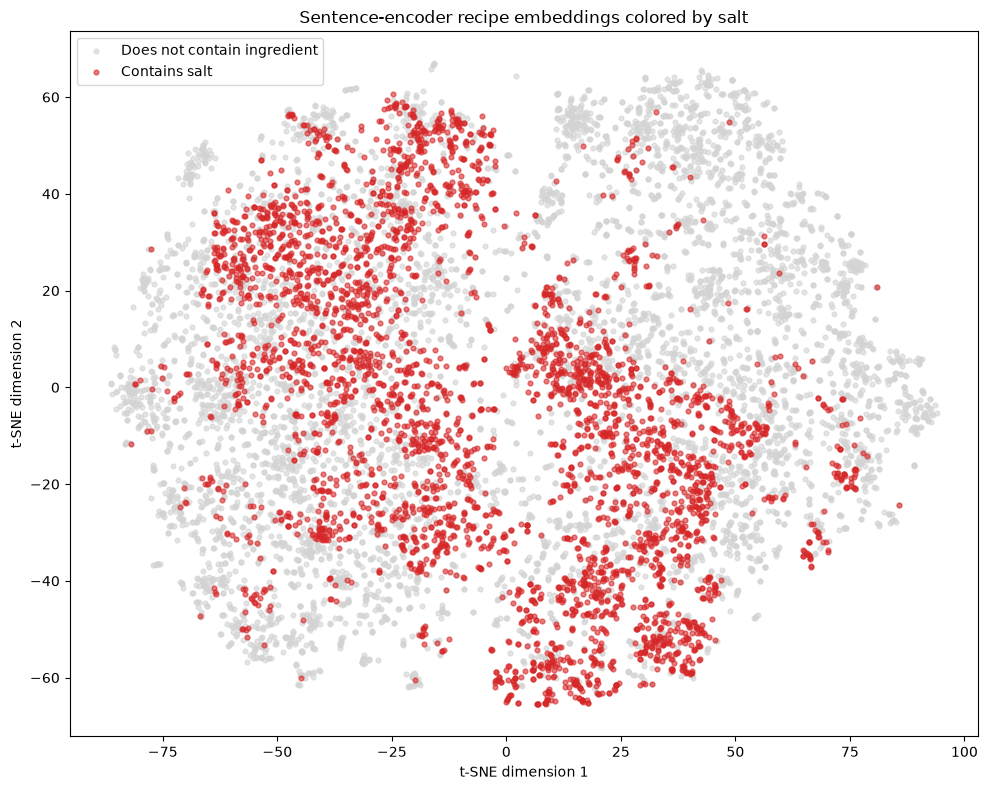

Recipes containing 'salt': 3,917
Other recipes: 5,912


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Sentence-encoder recipe embeddings colored by salt'}, xlabel='t-SNE dimension 1', ylabel='t-SNE dimension 2'>)

In [15]:
recipe_sentence_embeddings = np.load("data/processed/recipe_x_full.npy")

plot_embedding_by_ingredient(
    shared_ingredient,
    embeddings=recipe_sentence_embeddings,
    title=f"Sentence-encoder recipe embeddings colored by {shared_ingredient}"
)

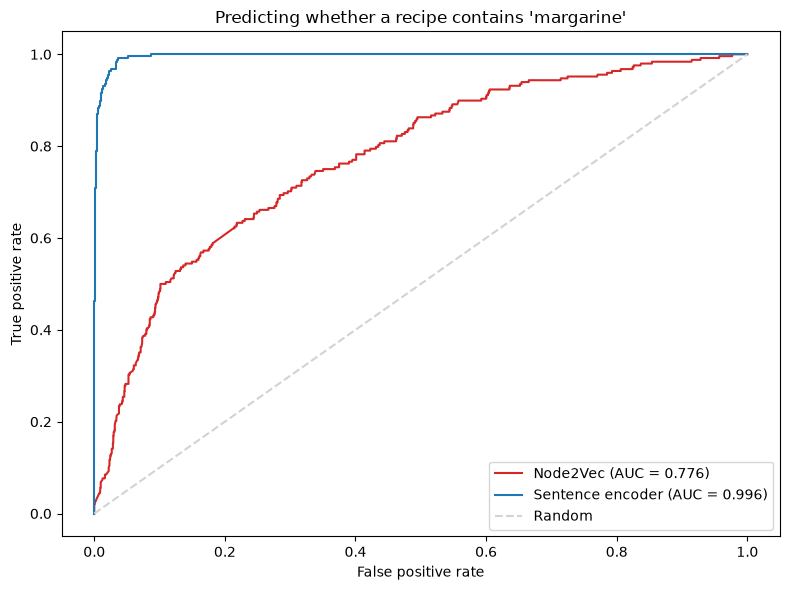

Ingredient: 'margarine'
Positive recipes: 1,238
Negative recipes: 8,591
Node2Vec held-out ROC AUC: 0.776
Sentence encoder held-out ROC AUC: 0.996


({'Node2Vec': {'classifier': LogisticRegression(max_iter=1000, random_state=0),
   'auc': 0.7759268560591837},
  'Sentence encoder': {'classifier': LogisticRegression(max_iter=1000, random_state=0),
   'auc': 0.9964864433512337}},
 <Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': "Predicting whether a recipe contains 'margarine'"}, xlabel='False positive rate', ylabel='True positive rate'>)

In [17]:
def plot_ingredient_auc(
    ingredient,
    embeddings_by_name,
    recipes_df=None,
    test_size=0.2,
    random_state=0,
    title=None,
    figsize=(8, 6),
):
    """Plot held-out ROC curves for multiple recipe embedding spaces."""
    if recipes_df is None:
        recipes_df = recipes

    if not embeddings_by_name:
        raise ValueError("embeddings_by_name must contain at least one embedding set.")
    if "ings" not in recipes_df:
        raise ValueError("recipes_df must contain an 'ings' column.")

    ingredient = ingredient.strip().lower()
    if not ingredient:
        raise ValueError("ingredient must not be empty.")

    labels = recipes_df["ings"].fillna("").map(
        lambda value: ingredient in {
            item.strip().lower() for item in value.split("|") if item.strip()
        }
    ).to_numpy(dtype=np.int64)

    if labels.sum() == 0 or labels.sum() == len(labels):
        raise ValueError(
            f"'{ingredient}' must occur in both positive and negative recipe classes."
        )

    indices = np.arange(len(labels))
    train_indices, test_indices = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=labels,
    )

    figure, axis = plt.subplots(figsize=figsize)
    results = {}
    colors = ["tab:red", "tab:blue", "tab:green", "tab:orange"]

    for (name, embedding_values), color in zip(embeddings_by_name.items(), colors):
        embeddings = np.asarray(embedding_values)
        if len(embeddings) != len(recipes_df):
            raise ValueError(
                f"'{name}' embeddings must match the number of recipe rows."
            )

        classifier = LogisticRegression(max_iter=1000, random_state=random_state)
        classifier.fit(embeddings[train_indices], labels[train_indices])
        probabilities = classifier.predict_proba(embeddings[test_indices])[:, 1]

        false_positive_rate, true_positive_rate, _ = roc_curve(
            labels[test_indices], probabilities
        )
        auc = roc_auc_score(labels[test_indices], probabilities)
        axis.plot(
            false_positive_rate,
            true_positive_rate,
            color=color,
            label=f"{name} (AUC = {auc:.3f})",
        )
        results[name] = {"classifier": classifier, "auc": auc}

    axis.plot([0, 1], [0, 1], linestyle="--", color="lightgray", label="Random")
    axis.set_title(title or f"Predicting whether a recipe contains '{ingredient}'")
    axis.set_xlabel("False positive rate")
    axis.set_ylabel("True positive rate")
    axis.legend(loc="lower right")
    figure.tight_layout()
    plt.show()

    print(f"Ingredient: {ingredient!r}")
    print(f"Positive recipes: {labels.sum():,}")
    print(f"Negative recipes: {(labels == 0).sum():,}")
    for name, result in results.items():
        print(f"{name} held-out ROC AUC: {result['auc']:.3f}")

    return results, figure, axis


plot_ingredient_auc(
    'margarine',
    embeddings_by_name={
        "Node2Vec": node2vec["recipe_embeddings"],
        "Sentence encoder": recipe_sentence_embeddings,
    }
)